/tmp/ipykernel_13634/322388495.py:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(2, len(all_edges)))


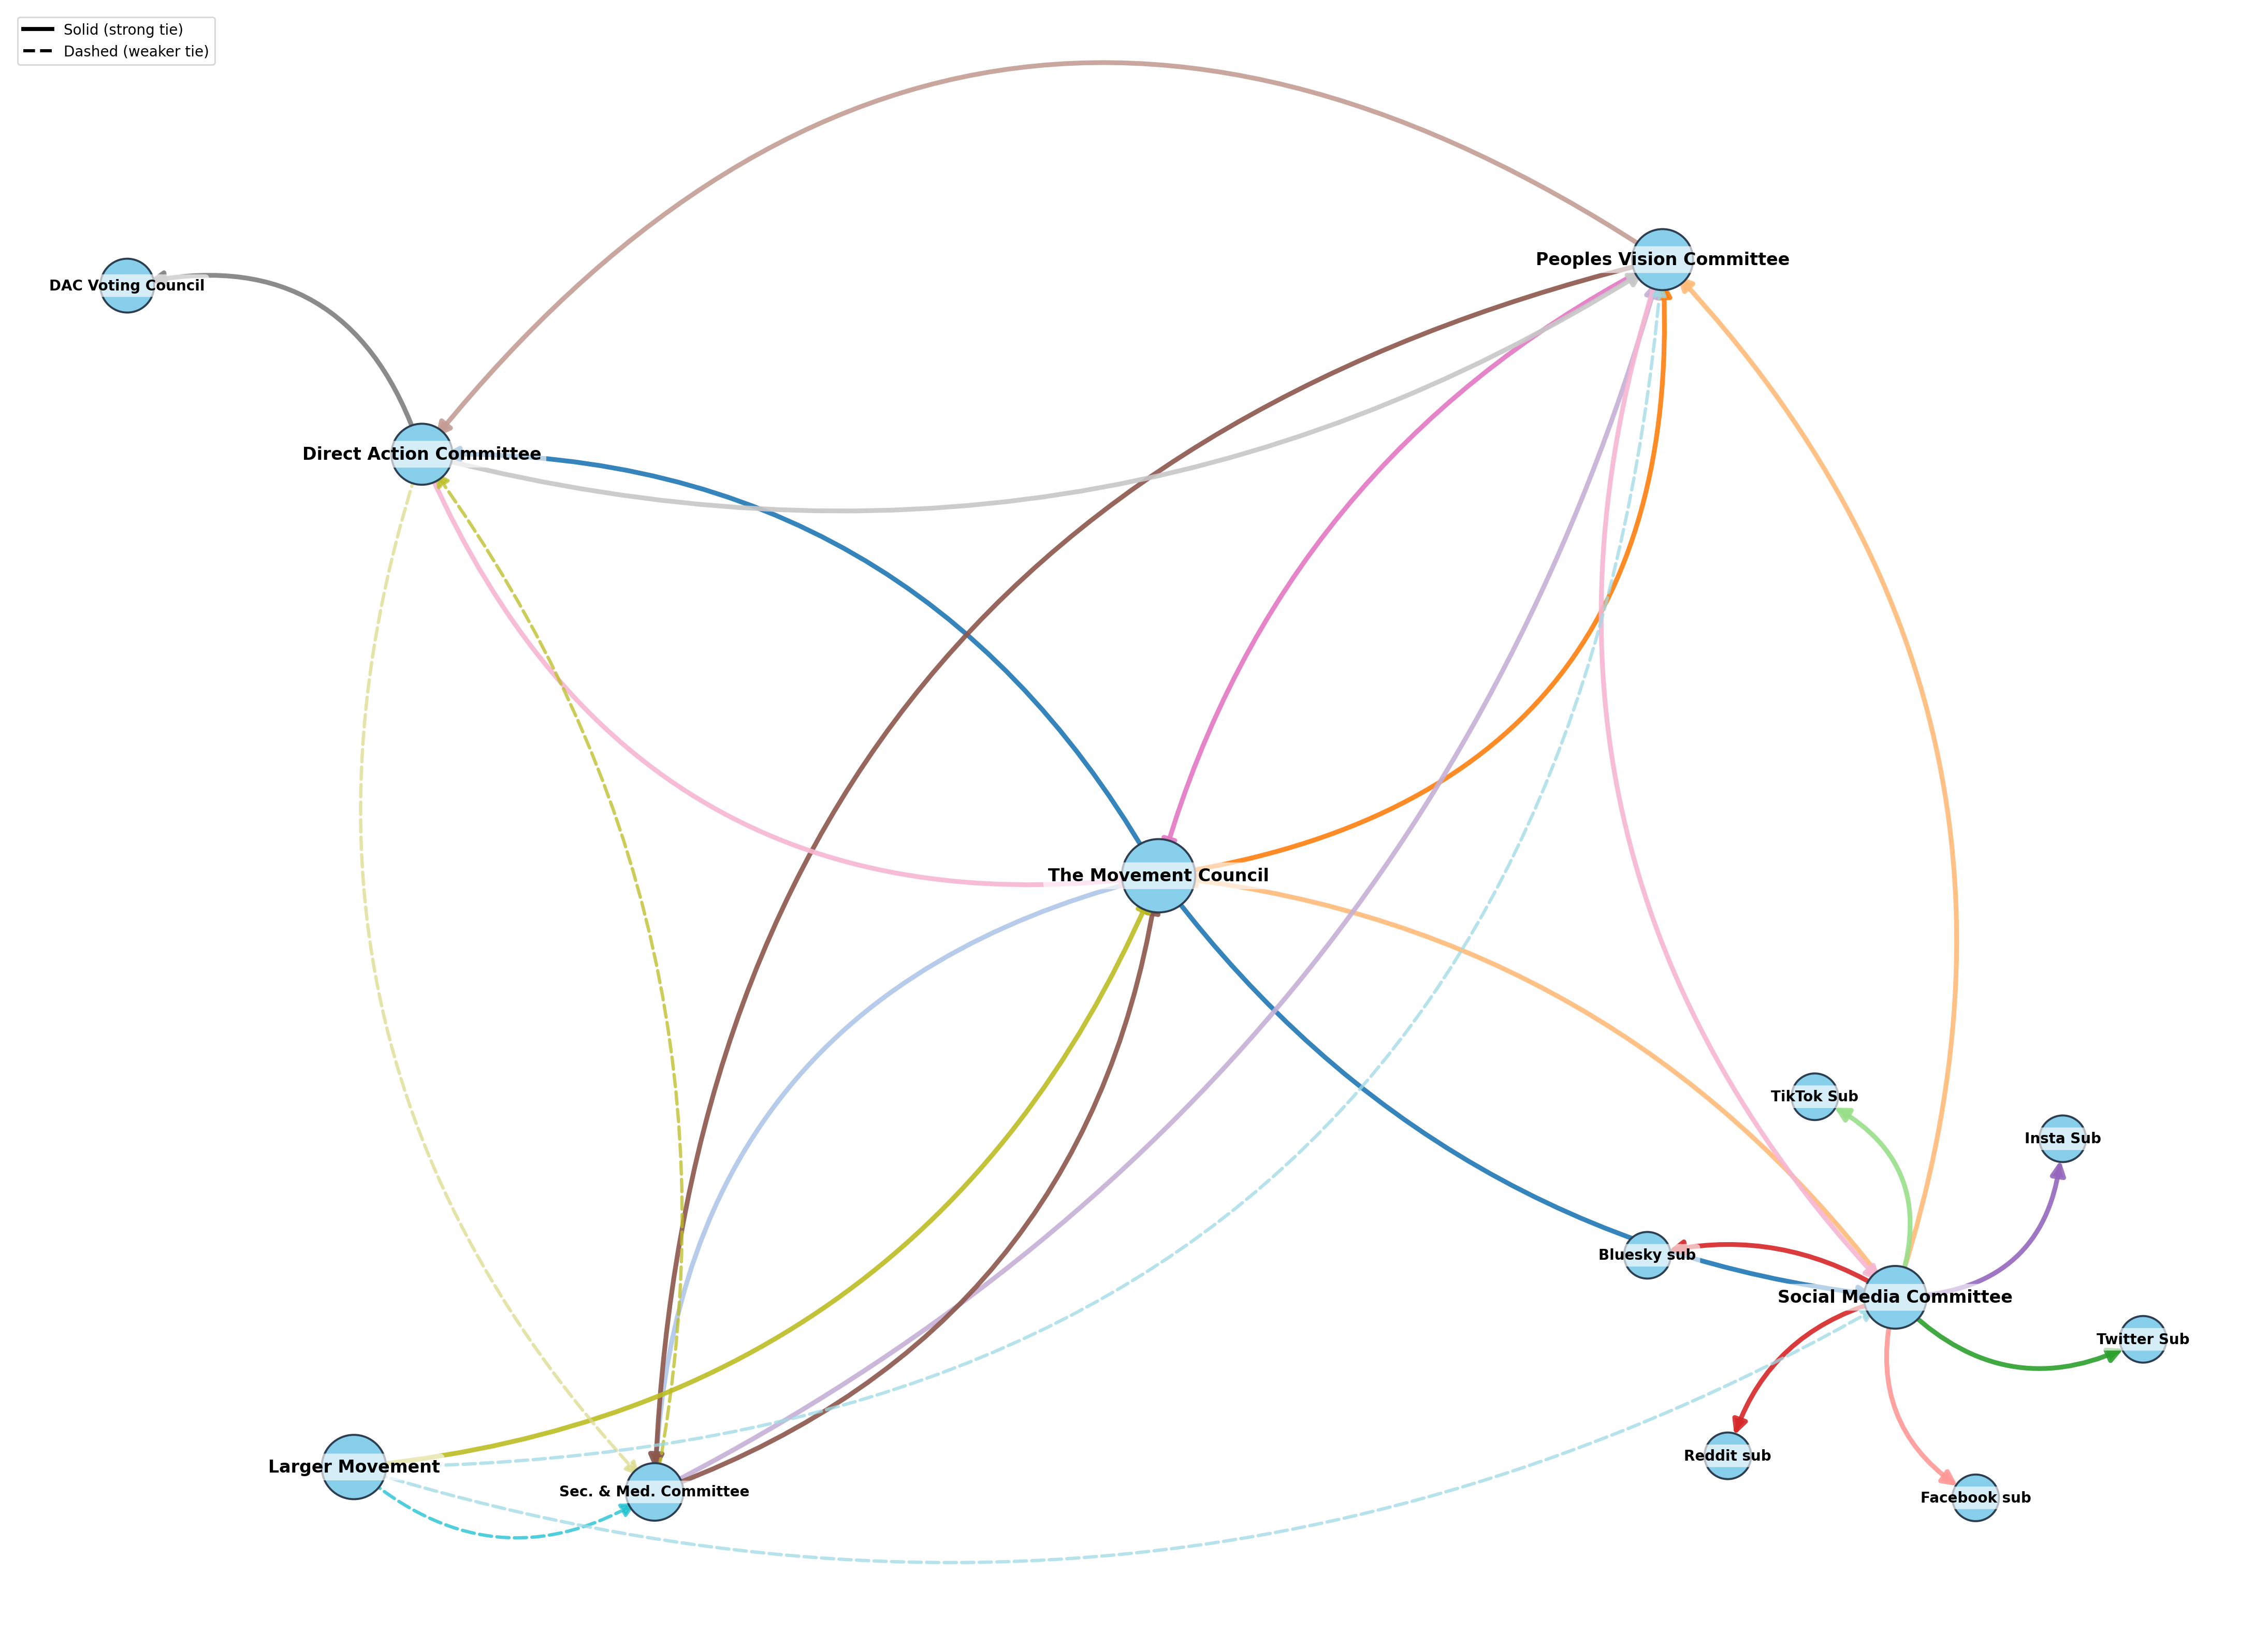

Saved to movement_graph_cluster_legible_anchored.png


In [97]:
# Movement graph — council center; committees on wide ring; SMC subs clustered near SMC.
# Legibility: unique edge colors, curved edges, arrowheads offset from nodes.
# Anchors: place DAC Voting Council near Direct Action Committee; pull Larger Movement inward.

import math
import numpy as np
import matplotlib.cm as cm
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

G = nx.DiGraph()

# --- Visual metadata ---
node_size = {
    "The Movement Council": 2600,
    "Social Media Committee": 1900,
    "Sec. & Med. Committee": 1600,
    "Peoples Vision Committee": 1800,
    "Direct Action Committee": 1800,
    "DAC Voting Council": 1400,
    "Twitter Sub": 1050,
    "Insta Sub": 1050,
    "TikTok Sub": 1050,
    "Bluesky sub": 1050,
    "Reddit sub": 1050,
    "Facebook sub": 1050,
    "Larger Movement": 2000,
}
label_size = {n: (12 if node_size[n] >= 1800 else 10) for n in node_size}
G.add_nodes_from(node_size.keys())

def add(u, v, w=1.0, layout_w=None):
    if layout_w is None:
        layout_w = w
    G.add_edge(u, v, weight=w, layout_w=layout_w)

# --- Edges ---
add("The Movement Council", "Social Media Committee", 1, layout_w=2.0)
add("The Movement Council", "Direct Action Committee", 1, layout_w=1.6)
add("The Movement Council", "Sec. & Med. Committee", 1, layout_w=1.6)
add("The Movement Council", "Peoples Vision Committee", 1, layout_w=1.6)

add("Sec. & Med. Committee", "Peoples Vision Committee", 1)
add("Sec. & Med. Committee", "The Movement Council", 1)
add("Sec. & Med. Committee", "Direct Action Committee", 0.5)

add("Peoples Vision Committee", "Sec. & Med. Committee", 1)
add("Peoples Vision Committee", "Direct Action Committee", 1, layout_w=1.8)
add("Peoples Vision Committee", "The Movement Council", 1)
add("Peoples Vision Committee", "Social Media Committee", 1, layout_w=1.7)

add("Direct Action Committee", "The Movement Council", 1)
add("Direct Action Committee", "DAC Voting Council", 1, layout_w=1.8)
add("Direct Action Committee", "Peoples Vision Committee", 1)
add("Direct Action Committee", "Sec. & Med. Committee", 0.5)

add("Social Media Committee", "The Movement Council", 1)
add("Social Media Committee", "Peoples Vision Committee", 1)

for sub in ["Twitter Sub","TikTok Sub","Bluesky sub","Reddit sub","Facebook sub","Insta Sub"]:
    add("Social Media Committee", sub, 1, layout_w=3.0)

add("Larger Movement", "The Movement Council", 1)
add("Larger Movement", "Sec. & Med. Committee", 0.5)
add("Larger Movement", "Peoples Vision Committee", 0.5)
add("Larger Movement", "Social Media Committee", 0.5)

# --- Deterministic layout with anchors ---
center = "The Movement Council"
committees_order = [
    "Social Media Committee",
    "Peoples Vision Committee",
    "Direct Action Committee",
    "Sec. & Med. Committee",
]
smc_subs = ["Twitter Sub","Insta Sub","TikTok Sub","Bluesky sub","Reddit sub","Facebook sub"]

# radii
R_COMMS = 3.0
R_SUBCLUSTER = 0.85
R_OUTER_DAC = 4.2      # DAC Voting Council distance (near its parent)
R_OUTER_LARGER = 3.6   # pull Larger Movement inward for more "centrality"

SMC_THETA = -0.6  # rotate whole picture

def ring_positions(nodes, radius, theta0=0.0):
    if not nodes:
        return {}
    step = 2 * math.pi / len(nodes)
    return {
        node: (radius * math.cos(theta0 + i * step),
               radius * math.sin(theta0 + i * step))
        for i, node in enumerate(nodes)
    }

pos = {}
pos[center] = (0.0, 0.0)

# Committees around center
comm_pos = ring_positions(committees_order, R_COMMS, theta0=SMC_THETA)
pos.update(comm_pos)

# Subcluster around SMC
cx, cy = comm_pos["Social Media Committee"]
sub_pos = ring_positions(smc_subs, R_SUBCLUSTER, theta0=SMC_THETA + 0.4)
for n, (x, y) in sub_pos.items():
    pos[n] = (cx + x, cy + y)

# --- Anchor DAC Voting Council near Direct Action Committee ---
dx, dy = comm_pos["Direct Action Committee"]
theta_dac = math.atan2(dy, dx)  # angle of DAC committee
pos["DAC Voting Council"] = (R_OUTER_DAC * math.cos(theta_dac),
                             R_OUTER_DAC * math.sin(theta_dac))

# --- Pull Larger Movement inward and align it roughly toward Sec & Med Committee ---
sx, sy = comm_pos["Sec. & Med. Committee"]
theta_smc = math.atan2(sy, sx)
pos["Larger Movement"] = (R_OUTER_LARGER * math.cos(theta_smc - 0.25),
                          R_OUTER_LARGER * math.sin(theta_smc - 0.25))

# --- Draw with legibility upgrades ---
def edge_width(e):
    w = G.edges[e].get("weight", 1)
    return 1.3 + 2.0 * w

solid_edges  = [(u, v) for u, v, d in G.edges(data=True) if d.get("weight", 1) >= 1]
dashed_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("weight", 1) < 1]
all_edges = solid_edges + dashed_edges

cmap = cm.get_cmap('tab20', max(2, len(all_edges)))
edge_color = {e: cmap(i) for i, e in enumerate(all_edges)}

plt.figure(figsize=(22, 16), dpi=200)

nx.draw_networkx_nodes(
    G, pos,
    node_size=[node_size[n] for n in G.nodes()],
    node_color="skyblue",
    linewidths=1.4,
    edgecolors="#2c3e50"
)

for n, (x, y) in pos.items():
    plt.text(
        x, y, n,
        fontsize=label_size.get(n, 10),
        ha="center", va="center",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.28", fc="white", ec="none", alpha=0.65)
    )

def draw_edges(edge_list, style):
    for i, e in enumerate(edge_list):
        rad = 0.22 + (i % 4) * 0.08  # vary curvature to reduce overlaps
        kwargs = dict(
            edgelist=[e],
            width=[edge_width(e)],
            alpha=0.9 if style == "solid" else 0.75,
            style=style,
            arrowstyle="-|>",
            arrowsize=20,
            connectionstyle=f"arc3,rad={rad}",
            edge_color=edge_color[e],
        )
        try:
            kwargs["min_source_margin"] = 15
            kwargs["min_target_margin"] = 15
        except Exception:
            pass
        nx.draw_networkx_edges(G, pos, **kwargs)

draw_edges(solid_edges, "solid")
draw_edges(dashed_edges, "dashed")

plt.axis("off")
plt.tight_layout()

legend_lines = [
    Line2D([0], [0], color="k", lw=2.8, label="Solid (strong tie)"),
    Line2D([0], [0], color="k", lw=2.2, linestyle="--", label="Dashed (weaker tie)")
]
plt.legend(handles=legend_lines, loc="upper left")

outfile = "movement_graph_cluster_legible_anchored.png"
plt.savefig(outfile, bbox_inches="tight")
plt.show()
print(f"Saved to {outfile}")


In [98]:
deg_cent = nx.degree_centrality(G)
print("Degree Centrality:")
for n, c in sorted(deg_cent.items(), key=lambda x: x[1], reverse=True):
    print(f"{n:25s} {c:.3f}")


Degree Centrality:
Social Media Committee    0.917
The Movement Council      0.750
Peoples Vision Committee  0.750
Sec. & Med. Committee     0.583
Direct Action Committee   0.583
Larger Movement           0.333
DAC Voting Council        0.083
Twitter Sub               0.083
Insta Sub                 0.083
TikTok Sub                0.083
Bluesky sub               0.083
Reddit sub                0.083
Facebook sub              0.083


In [99]:
print("\nIn-Degree:")
for n, d in G.in_degree():
    print(f"{n:25s} {d}")
    
print("\nOut-Degree:")
for n, d in G.out_degree():
    print(f"{n:25s} {d}")



In-Degree:
The Movement Council      5
Social Media Committee    3
Sec. & Med. Committee     4
Peoples Vision Committee  5
Direct Action Committee   3
DAC Voting Council        1
Twitter Sub               1
Insta Sub                 1
TikTok Sub                1
Bluesky sub               1
Reddit sub                1
Facebook sub              1
Larger Movement           0

Out-Degree:
The Movement Council      4
Social Media Committee    8
Sec. & Med. Committee     3
Peoples Vision Committee  4
Direct Action Committee   4
DAC Voting Council        0
Twitter Sub               0
Insta Sub                 0
TikTok Sub                0
Bluesky sub               0
Reddit sub                0
Facebook sub              0
Larger Movement           4


In [100]:
bet_cent = nx.betweenness_centrality(G, normalized=True, weight='weight')
print("\nBetweenness Centrality:")
for n, c in sorted(bet_cent.items(), key=lambda x: x[1], reverse=True):
    print(f"{n:25s} {c:.3f}")



Betweenness Centrality:
Social Media Committee    0.227
The Movement Council      0.064
Peoples Vision Committee  0.064
Direct Action Committee   0.038
Sec. & Med. Committee     0.015
DAC Voting Council        0.000
Twitter Sub               0.000
Insta Sub                 0.000
TikTok Sub                0.000
Bluesky sub               0.000
Reddit sub                0.000
Facebook sub              0.000
Larger Movement           0.000


In [101]:
close_cent = nx.closeness_centrality(G, distance=None)
print("\nCloseness Centrality:")
for n, c in sorted(close_cent.items(), key=lambda x: x[1], reverse=True):
    print(f"{n:25s} {c:.3f}")



Closeness Centrality:
The Movement Council      0.417
Peoples Vision Committee  0.417
Sec. & Med. Committee     0.347
Social Media Committee    0.298
Direct Action Committee   0.298
DAC Voting Council        0.231
Twitter Sub               0.231
Insta Sub                 0.231
TikTok Sub                0.231
Bluesky sub               0.231
Reddit sub                0.231
Facebook sub              0.231
Larger Movement           0.000


In [102]:
print("\nStrongly Connected Components:")
for comp in nx.strongly_connected_components(G):
    print(comp)



Strongly Connected Components:
{'DAC Voting Council'}
{'Twitter Sub'}
{'TikTok Sub'}
{'Bluesky sub'}
{'Reddit sub'}
{'Facebook sub'}
{'Insta Sub'}
{'Social Media Committee', 'Peoples Vision Committee', 'The Movement Council', 'Direct Action Committee', 'Sec. & Med. Committee'}
{'Larger Movement'}


In [103]:
src, tgt = "Larger Movement", "Twitter Sub"
path = nx.shortest_path(G, source=src, target=tgt, weight=None)
print(f"\nShortest path from {src} to {tgt}: {path}")



Shortest path from Larger Movement to Twitter Sub: ['Larger Movement', 'Social Media Committee', 'Twitter Sub']


In [104]:
assort = nx.degree_assortativity_coefficient(G)
print(f"\nDegree Assortativity Coefficient: {assort:.3f}")



Degree Assortativity Coefficient: -0.566
